In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    RandomizedSearchCV,
    TimeSeriesSplit
)

from xgboost import XGBRegressor

# Machine Learning Demand Forecasting

This notebook develops and evaluates machine learning models for forecasting **daily demand at store-product level from 1 to 7 days ahead**.

The preprocessed dataset from the analysis stage contains historical demand features and business variables. This notebook restructures those observations into forecast-origin and forecast-date pairs, applies a chronological train-test split, compares multiple regression models, and selects the strongest model based on unseen future data.

## 1. Load Preprocessed Data

In [2]:
df=pd.read_csv('data/preprocessed_demand_forecasting.csv')

## 2. Forecast Target Construction

The modelling objective is to predict **daily demand for each of the next seven days** at store-product level.

For every forecast origin, seven prediction horizons are created:

- Horizon 1: next-day demand
- Horizon 2: demand two days ahead
- ...
- Horizon 7: demand seven days ahead

Each horizon is treated as a separate forecast observation, allowing one model to learn across the complete 7-day forecasting window.

In [3]:
for day in range(1, 8):
    df[f'Demand_Day_{day}'] = (
        df.groupby(['Store ID', 'Product ID'])['Demand']
          .shift(-day)
    )

In [4]:
df[
    [
        'Date',
        'Store ID',
        'Product ID',
        'Demand',
        'Demand_Day_1',
        'Demand_Day_2',
        'Demand_Day_3',
        'Demand_Day_4',
        'Demand_Day_5',
        'Demand_Day_6',
        'Demand_Day_7'
    ]
].head()



,Date,Store ID,Product ID,Demand,Demand_Day_1,Demand_Day_2,Demand_Day_3,Demand_Day_4,Demand_Day_5,Demand_Day_6,Demand_Day_7
0,2022-01-01,S001,P0001,115,84.0,132.0,67.0,110.0,146.0,87.0,113.0
1,2022-01-02,S001,P0001,84,132.0,67.0,110.0,146.0,87.0,113.0,87.0
2,2022-01-03,S001,P0001,132,67.0,110.0,146.0,87.0,113.0,87.0,99.0
3,2022-01-04,S001,P0001,67,110.0,146.0,87.0,113.0,87.0,99.0,103.0
4,2022-01-05,S001,P0001,110,146.0,87.0,113.0,87.0,99.0,103.0,85.0


### Historical Feature Availability

Lagged and rolling-demand variables contain missing values at the beginning of each store-product series because insufficient historical observations are available. These incomplete rows are removed before forecast observations are created.

In [5]:
df[
    [
        'Demand_Lag_1',
        'Demand_Lag_7',
        'Demand_Lag_14',
        'Demand_Rolling_7'
    ]
].isna().sum()

Demand_Lag_1         100
Demand_Lag_7         700
Demand_Lag_14       1400
Demand_Rolling_7     700
dtype: int64

In [6]:
df = df.dropna(
    subset=[
        'Demand_Lag_1',
        'Demand_Lag_7',
        'Demand_Lag_14',
        'Demand_Rolling_7'
    ]
).copy()

print("Rows after removing incomplete historical features:", len(df))

Rows after removing incomplete historical features: 74600


## 3. Forecast-Date Dataset Construction

The modelling dataset is restructured so that each row represents a forecast made on a specific date for a specific future horizon.

Historical demand features remain anchored to the forecast origin, while business conditions such as price, promotion, weather, competitor pricing, seasonality and calendar information are aligned with the corresponding forecast date.

Future demand on that forecast date becomes `Target_Demand`.

In [7]:
forecast_rows = []

future_features = [
    'Price',
    'Discount',
    'Weather Condition',
    'Promotion',
    'Competitor Pricing',
    'Seasonality',
    'Epidemic',
    'Year',
    'Month',
    'Day',
    'Weekday',
    'Discounted_Price'
]

historical_features = [
    'Demand_Lag_1',
    'Demand_Lag_7',
    'Demand_Lag_14',
    'Demand_Rolling_7'
]

for horizon in range(1, 8):

    temp = df[
        [
            'Date',
            'Store ID',
            'Product ID',
            'Category',
            'Region'
        ] + historical_features
    ].copy()

    temp['Forecast_Horizon'] = horizon

    temp['Forecast_Date'] = (
        df.groupby(['Store ID', 'Product ID'])['Date']
        .shift(-horizon)
    )

    for feature in future_features:
        temp[feature] = (
            df.groupby(['Store ID', 'Product ID'])[feature]
            .shift(-horizon)
        )

    temp['Target_Demand'] = df[f'Demand_Day_{horizon}']

    forecast_rows.append(temp)

forecast_df = pd.concat(
    forecast_rows,
    ignore_index=True
)

In [8]:
forecast_df.head(14)

,Date,Store ID,Product ID,Category,Region,Demand_Lag_1,Demand_Lag_7,Demand_Lag_14,Demand_Rolling_7,Forecast_Horizon,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Year,Month,Day,Weekday,Discounted_Price,Target_Demand
0,2022-01-15,S001,P0001,Electronics,North,52.0,113.0,115.0,88.000000,1,...,0.0,81.10,Winter,0.0,2022.0,1.0,16.0,Sunday,64.053,126.0
1,2022-01-16,S001,P0001,Electronics,North,175.0,87.0,84.0,96.857143,1,...,1.0,61.83,Winter,0.0,2022.0,1.0,17.0,Monday,49.480,102.0
2,2022-01-17,S001,P0001,Electronics,North,126.0,99.0,132.0,102.428571,1,...,0.0,61.25,Winter,0.0,2022.0,1.0,18.0,Tuesday,62.667,102.0
3,2022-01-18,S001,P0001,Electronics,North,102.0,103.0,67.0,102.857143,1,...,0.0,83.08,Winter,0.0,2022.0,1.0,19.0,Wednesday,63.531,123.0
4,2022-01-19,S001,P0001,Electronics,North,102.0,85.0,110.0,102.714286,1,...,0.0,58.54,Winter,0.0,2022.0,1.0,20.0,Thursday,44.523,25.0
5,2022-01-20,S001,P0001,Electronics,North,123.0,77.0,146.0,108.142857,1,...,0.0,63.13,Winter,0.0,2022.0,1.0,21.0,Friday,60.066,90.0
6,2022-01-21,S001,P0001,Electronics,North,25.0,52.0,87.0,100.714286,1,...,0.0,74.80,Winter,0.0,2022.0,1.0,22.0,Saturday,77.180,102.0
7,2022-01-22,S001,P0001,Electronics,North,90.0,175.0,113.0,106.142857,1,...,1.0,65.08,Winter,0.0,2022.0,1.0,23.0,Sunday,60.129,126.0
8,2022-01-23,S001,P0001,Electronics,North,102.0,126.0,87.0,95.714286,1,...,1.0,45.06,Winter,0.0,2022.0,1.0,24.0,Monday,35.235,44.0
9,2022-01-24,S001,P0001,Electronics,North,126.0,102.0,99.0,95.714286,1,...,0.0,56.00,Winter,0.0,2022.0,1.0,25.0,Tuesday,54.162,61.0


## 4. Model Features and Target

The model combines store-product information, historical demand signals, forecast horizon, forecast-date business conditions, and calendar features.

`Target_Demand` represents demand on the corresponding forecast date.

In [9]:
target = 'Target_Demand'

feature_columns = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',

    # Historical demand information
    'Demand_Lag_1',
    'Demand_Lag_7',
    'Demand_Lag_14',
    'Demand_Rolling_7',

    # How far ahead we are forecasting
    'Forecast_Horizon',

    # Future-known/planned information
    'Price',
    'Discount',
    'Promotion',
    'Weather Condition',
    'Competitor Pricing',
    'Seasonality',
    'Epidemic',

    # Calendar information for the forecast date
    'Year',
    'Month',
    'Day',
    'Weekday',

    # Derived price information
    'Discounted_Price'
]

In [10]:
required_future_features = [
    'Price',
    'Discount',
    'Promotion',
    'Weather Condition',
    'Competitor Pricing',
    'Seasonality',
    'Epidemic',
    'Year',
    'Month',
    'Day',
    'Weekday',
    'Discounted_Price'
]

forecast_df = forecast_df.dropna(
    subset=required_future_features
).copy()

forecast_df = forecast_df.reset_index(drop=True)

print("Final forecast dataset shape:", forecast_df.shape)

Final forecast dataset shape: (519400, 24)


In [11]:
X = forecast_df[feature_columns].copy()
y = forecast_df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (519400, 21)
y shape: (519400,)


## 5. Chronological Train-Test Split

Because this is a forecasting problem, observations are split chronologically rather than randomly.

The final three months are reserved as the held-out test period. A 7-day separation is maintained between the latest training forecast origins and the test period so that training targets do not overlap with future test observations.

In [12]:
forecast_df['Date'] = pd.to_datetime(forecast_df['Date'])
forecast_df['Forecast_Date'] = pd.to_datetime(
    forecast_df['Forecast_Date']
)

In [13]:
cutoff_date = (forecast_df['Date'].max() - pd.DateOffset(months=3))

cutoff_date

Timestamp('2023-10-29 00:00:00')

In [14]:
forecast_horizon = 7

train_end_date = (cutoff_date - pd.Timedelta(days=forecast_horizon))

train_mask = ((forecast_df['Date'] <= train_end_date) &(forecast_df['Forecast_Date'] <= cutoff_date))

test_mask = (forecast_df['Date'] > cutoff_date)

In [15]:
X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

In [16]:
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print(
    "\nTraining forecast origins:",
    forecast_df.loc[train_mask, 'Date'].min(),
    "to",
    forecast_df.loc[train_mask, 'Date'].max()
)

print(
    "Training target dates:",
    forecast_df.loc[train_mask, 'Forecast_Date'].min(),
    "to",
    forecast_df.loc[train_mask, 'Forecast_Date'].max()
)

print(
    "\nTest forecast origins:",
    forecast_df.loc[test_mask, 'Date'].min(),
    "to",
    forecast_df.loc[test_mask, 'Date'].max()
)

print(
    "Test target dates:",
    forecast_df.loc[test_mask, 'Forecast_Date'].min(),
    "to",
    forecast_df.loc[test_mask, 'Forecast_Date'].max()
)

Training rows: 452200
Test rows: 62300

Training forecast origins: 2022-01-15 00:00:00 to 2023-10-22 00:00:00
Training target dates: 2022-01-16 00:00:00 to 2023-10-29 00:00:00

Test forecast origins: 2023-10-30 00:00:00 to 2024-01-29 00:00:00
Test target dates: 2023-10-31 00:00:00 to 2024-01-30 00:00:00


## 6. Feature Preprocessing

Categorical variables are one-hot encoded using categories learned from the training data. Numerical variables are passed through unchanged.

The preprocessing transformation is fitted only on the training set and then applied to the held-out test set.

In [17]:
categorical_features = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Weather Condition',
    'Seasonality',
    'Weekday'
]

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [19]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

X_train_encoded shape: (452200, 63)
X_test_encoded shape: (62300, 63)


## 7. Baseline Forecast

A simple baseline forecast is established before training machine learning models.

The baseline uses the recent 7-day rolling average demand as the prediction for each forecast observation. This provides a benchmark that subsequent models must outperform.

In [20]:
baseline_predictions = X_test['Demand_Rolling_7'].values

In [21]:
baseline_by_horizon = pd.DataFrame({
    'Forecast_Horizon': X_test['Forecast_Horizon'],
    'Actual': y_test.values,
    'Prediction': baseline_predictions
})

baseline_horizon_results = (
    baseline_by_horizon
    .groupby('Forecast_Horizon')
    .apply(
        lambda group: mean_absolute_error(
            group['Actual'],
            group['Prediction']
        )
    )
    .reset_index(name='MAE')
)

baseline_horizon_results.round(2)

,Forecast_Horizon,MAE
0,1,32.51
1,2,33.17
2,3,33.83
3,4,34.42
4,5,35.23
5,6,35.87
6,7,36.41


In [22]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Overall Baseline Performance")
print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R²: {baseline_r2:.2f}")

Overall Baseline Performance
Baseline MAE: 34.46
Baseline RMSE: 43.98
Baseline R²: 0.01


### Baseline Performance

The baseline achieved an MAE of **34.46**, RMSE of **43.98**, and R² of **0.01**.

Forecast error increased gradually from Day 1 to Day 7, providing a clear benchmark for evaluating whether machine learning models improve short-term demand forecasts.

## 8. Linear Regression

Linear Regression is evaluated as the first machine learning model to test whether the full feature set improves upon the baseline.

The model uses historical demand signals together with store, product, pricing, promotion, weather, competitor, seasonal, calendar, and forecast-horizon information.

In [23]:
linear_model = LinearRegression()

In [24]:
linear_model.fit(X_train_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](63,)","[ 0.24,-1.37,-0.57,..., 0.14, 0. ,-0.54]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1111
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,63
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(53)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](63,)","[49481.25,38634.07,27907.97,..., 0. , 0. , 0. ]"


In [25]:
linear_predictions = linear_model.predict(X_test_encoded)

In [26]:
linear_predictions.shape

(62300,)

In [27]:
linear_by_horizon = pd.DataFrame({
    'Forecast_Horizon': X_test['Forecast_Horizon'],
    'Actual': y_test.values,
    'Prediction': linear_predictions
})

linear_horizon_results = (
    linear_by_horizon
    .groupby('Forecast_Horizon')
    .apply(
        lambda group: mean_absolute_error(
            group['Actual'],
            group['Prediction']
        )
    )
    .reset_index(name='MAE')
)

linear_horizon_results.round(2)

,Forecast_Horizon,MAE
0,1,25.92
1,2,26.04
2,3,26.12
3,4,26.20
4,5,26.29
5,6,26.32
6,7,26.42


In [28]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)
print(f"Overall Linear Regression")
print(f"Linear Regression MAE: {linear_mae:.2f}")
print(f"Linear Regression RMSE: {linear_rmse:.2f}")
print(f"Linear Regression R²: {linear_r2:.2f}")

Overall Linear Regression
Linear Regression MAE: 26.18
Linear Regression RMSE: 33.71
Linear Regression R²: 0.42


### Linear Regression Performance

Linear Regression improved substantially on the baseline, achieving an MAE of **26.18**, RMSE of **33.71**, and R² of **0.42**.

Performance remained relatively stable across the 7-day horizon, showing that the expanded feature set provides considerably more predictive information than the rolling-demand baseline alone.

## 9. Random Forest

Random Forest is evaluated to capture nonlinear relationships and interactions between demand, pricing, product characteristics, promotions, weather, and other forecasting features.

In [29]:
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_encoded,
    y_train
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [30]:
rf_predictions = rf_model.predict(X_test_encoded)

In [31]:
rf_by_horizon = pd.DataFrame({
    'Forecast_Horizon': X_test['Forecast_Horizon'].values,
    'Actual': y_test.values,
    'Prediction': rf_predictions
})

rf_horizon_results = (
    rf_by_horizon
    .groupby('Forecast_Horizon')
    .apply(
        lambda group: mean_absolute_error(
            group['Actual'],
            group['Prediction']
        )
    )
    .reset_index(name='MAE')
)

rf_horizon_results.round(2)

,Forecast_Horizon,MAE
0,1,9.49
1,2,9.53
2,3,9.53
3,4,9.50
4,5,9.51
5,6,9.53
6,7,9.57


In [32]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Overall Random Forest")
print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R²: {rf_r2:.2f}")

Overall Random Forest
Random Forest MAE: 9.52
Random Forest RMSE: 15.30
Random Forest R²: 0.88


### Random Forest Performance

Random Forest produced a substantial improvement over both the baseline and Linear Regression, with an MAE of **9.52**, RMSE of **15.30**, and R² of **0.88**.

The model also maintained similar performance across forecast horizons 1–7, making it the strongest model evaluated at this stage.

## 10. XGBoost

XGBoost is evaluated as an additional nonlinear ensemble model for comparison with Random Forest.

In [33]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_encoded,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [34]:
xgb_predictions = xgb_model.predict(X_test_encoded)

In [35]:
xgb_by_horizon = pd.DataFrame({
    'Forecast_Horizon': X_test['Forecast_Horizon'].values,
    'Actual': y_test.values,
    'Prediction': xgb_predictions
})

xgb_horizon_results = (
    xgb_by_horizon
    .groupby('Forecast_Horizon')
    .apply(
        lambda group: mean_absolute_error(
            group['Actual'],
            group['Prediction']
        )
    )
    .reset_index(name='MAE')
)

xgb_horizon_results.round(2)

,Forecast_Horizon,MAE
0,1,12.01
1,2,12.06
2,3,12.09
3,4,12.05
4,5,12.09
5,6,12.08
6,7,12.07


In [36]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("Overall XGBoost")
print(f"XGBoost MAE: {xgb_mae:.2f}")
print(f"XGBoost RMSE: {xgb_rmse:.2f}")
print(f"XGBoost R²: {xgb_r2:.2f}")

Overall XGBoost
XGBoost MAE: 12.06
XGBoost RMSE: 17.36
XGBoost R²: 0.85


### XGBoost Performance

XGBoost achieved an MAE of **12.06**, RMSE of **17.36**, and R² of **0.85**.

Although performance was strong, Random Forest remained the best-performing model across all three evaluation metrics.

## 11. Initial Model Comparison

In [37]:
model_comparison = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        baseline_mae,
        linear_mae,
        rf_mae,
        xgb_mae
    ],
    'RMSE': [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    'R²': [
        baseline_r2,
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

model_comparison.round(2)

,Model,MAE,RMSE,R²
0,Baseline,34.46,43.98,0.01
1,Linear Regression,26.18,33.71,0.42
2,Random Forest,9.52,15.30,0.88
3,XGBoost,12.06,17.36,0.85


### Initial Model Comparison

Random Forest achieved the lowest MAE and RMSE and the highest R² among the untuned models.

Because it performed best on the held-out test period, Random Forest was selected for hyperparameter tuning.

## 12. Random Forest Hyperparameter Tuning

A computationally efficient tuning strategy is used to determine whether a modest hyperparameter search can improve generalisation without performing an unnecessarily expensive full-data search.

### Efficient Hyperparameter Search

The most recent 40% of the training data is used for tuning, with two chronological validation folds and six randomly sampled parameter combinations.

The final selected configuration is subsequently retrained once on the full training set.

In [38]:
rf_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.7]
}

In [39]:
# Most recent 40% of the training data used for tuning
tuning_start = int(len(X_train) * 0.60)

X_tune = X_train.iloc[tuning_start:].copy()
y_tune = y_train.iloc[tuning_start:].copy()

X_tune_encoded = preprocessor.transform(X_tune)

print("Full training rows:", len(X_train))
print("Tuning rows:", len(X_tune))
print("Encoded tuning shape:", X_tune_encoded.shape)

Full training rows: 452200
Tuning rows: 180880
Encoded tuning shape: (180880, 63)


In [40]:
tuning_cv = TimeSeriesSplit(n_splits=2)

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_grid,
    n_iter=6,
    scoring='neg_mean_absolute_error',
    cv=tuning_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [41]:
rf_search.fit(X_tune_encoded, y_tune)

Fitting 2 folds for each of 6 candidates, totalling 12 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [15, 20, ...], 'max_features': ['sqrt', 0.7], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``re

In [42]:
print("Best parameters:")
print(rf_search.best_params_)

print("\nBest tuning validation MAE:")
print(-rf_search.best_score_)

Best parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 20}

Best tuning validation MAE:
11.726672870152328


In [43]:
final_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.7
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max

In [44]:
tuned_rf_predictions = final_rf.predict(X_test_encoded)

In [45]:
tuned_rf_mae = mean_absolute_error(
    y_test,
    tuned_rf_predictions
)

tuned_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_rf_predictions
    )
)

tuned_rf_r2 = r2_score(
    y_test,
    tuned_rf_predictions
)

print("Tuned Random Forest Performance")
print(f"Tuned Random Forest MAE: {tuned_rf_mae:.2f}")
print(f"Tuned Random Forest RMSE: {tuned_rf_rmse:.2f}")
print(f"Tuned Random Forest R²: {tuned_rf_r2:.2f}")

Tuned Random Forest Performance
Tuned Random Forest MAE: 12.50
Tuned Random Forest RMSE: 18.39
Tuned Random Forest R²: 0.83


### Hyperparameter Tuning Evaluation

The tuned Random Forest achieved an MAE of **12.50**, RMSE of **18.39**, and R² of **0.83**, which was worse than the original Random Forest.

The original untuned Random Forest was therefore retained as the preferred model.

## 13. Final Model Comparison

All models are compared on the same held-out test period using MAE, RMSE, and R².

The tuned Random Forest is included to determine whether hyperparameter optimisation improved performance relative to the original model.

In [46]:
model_comparison = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'Tuned Random Forest'
    ],
    'MAE': [
        baseline_mae,
        linear_mae,
        rf_mae,
        xgb_mae,
        tuned_rf_mae
    ],
    'RMSE': [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        xgb_rmse,
        tuned_rf_rmse
    ],
    'R²': [
        baseline_r2,
        linear_r2,
        rf_r2,
        xgb_r2,
        tuned_rf_r2
    ]
})

model_comparison.round(2)

,Model,MAE,RMSE,R²
0,Baseline,34.46,43.98,0.01
1,Linear Regression,26.18,33.71,0.42
2,Random Forest,9.52,15.30,0.88
3,XGBoost,12.06,17.36,0.85
4,Tuned Random Forest,12.50,18.39,0.83


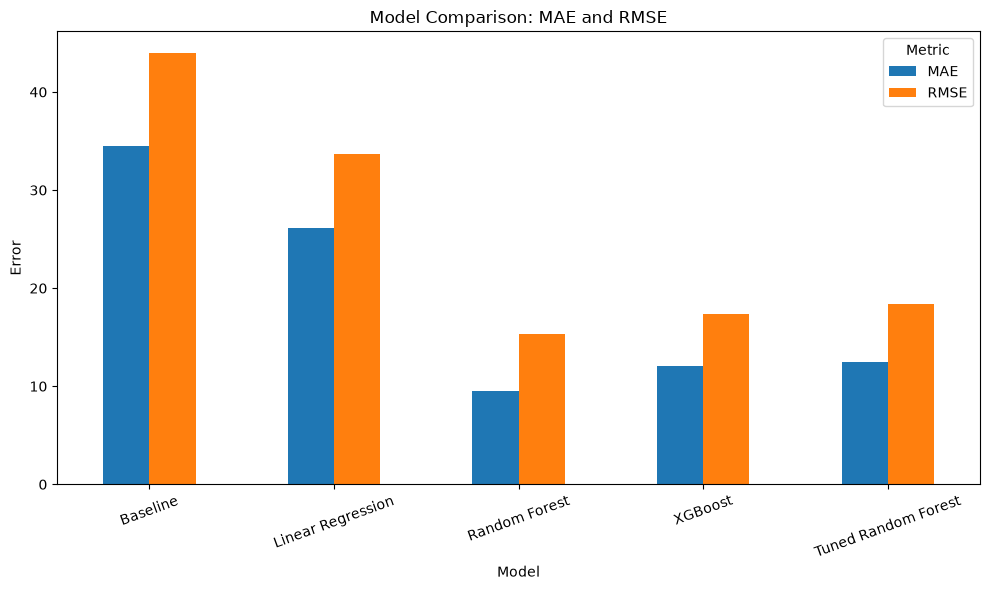

In [47]:
model_comparison.plot(
    x='Model',
    y=['MAE', 'RMSE'],
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Comparison: MAE and RMSE')
plt.ylabel('Error')
plt.xlabel('Model')
plt.xticks(rotation=20)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

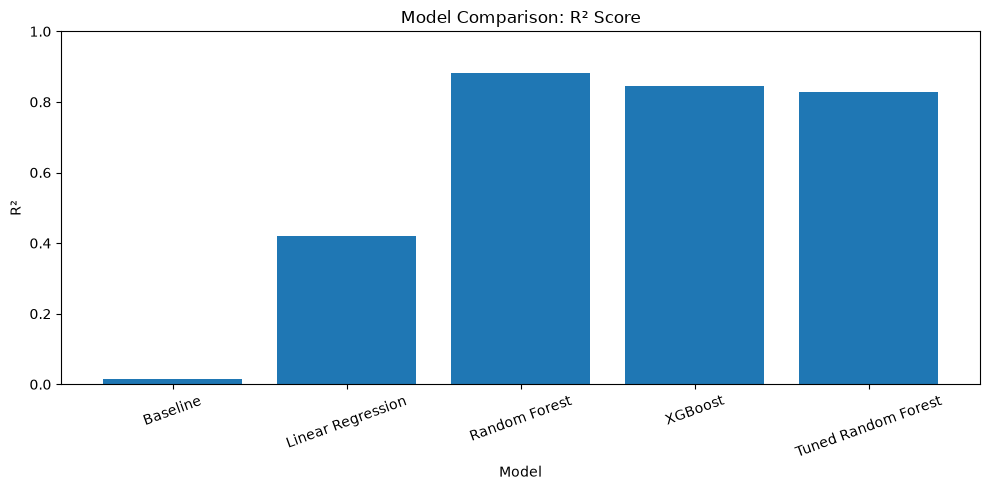

In [48]:
plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison['Model'],
    model_comparison['R²']
)

plt.title('Model Comparison: R² Score')
plt.ylabel('R²')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Final Model Selection

The original Random Forest is retained as the final forecasting model because it achieved the strongest overall performance on the held-out test period.

Hyperparameter tuning did not improve generalisation, so the untuned configuration was preferred for subsequent model interpretation and error analysis.

## 14. Random Forest Feature Importance

Feature importance is examined to identify the variables that contribute most strongly to the selected Random Forest model's predictions.

One-hot encoded categories are aggregated back to their original business features for clearer interpretation.

In [49]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

In [50]:
# Aggregate encoded categories back to original features
def get_original_feature(feature):
    
    feature = feature.replace('cat__', '').replace('remainder__', '')
    
    categorical_features = [
        'Store ID',
        'Product ID',
        'Category',
        'Region',
        'Weather Condition',
        'Seasonality',
        'Weekday'
    ]
    
    for original_feature in categorical_features:
        if feature.startswith(original_feature + '_'):
            return original_feature
    
    return feature


feature_importance['Original_Feature'] = (
    feature_importance['Feature'].apply(get_original_feature)
)

aggregated_importance = (
    feature_importance
    .groupby('Original_Feature', as_index=False)['Importance']
    .sum()
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

aggregated_importance

,Original_Feature,Importance
0,Price,0.195458
1,Category,0.183385
2,Product ID,0.142682
3,Epidemic,0.140585
4,Promotion,0.083863
5,Competitor Pricing,0.049881
6,Discount,0.032223
7,Store ID,0.028532
8,Weather Condition,0.028363
9,Discounted_Price,0.025159


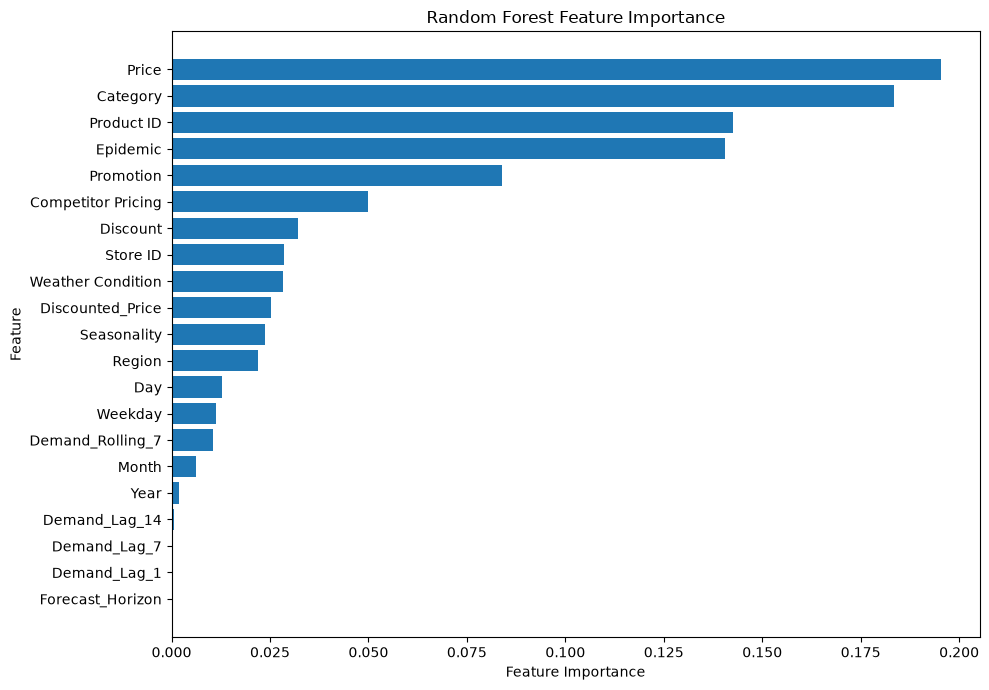

In [51]:
plt.figure(figsize=(10, 7))

plt.barh(
    aggregated_importance['Original_Feature'],
    aggregated_importance['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Feature Importance Summary

The Random Forest relies most strongly on **pricing, product characteristics, category, epidemic conditions, and promotion** when forecasting demand.

Commercial and contextual variables such as competitor pricing, discounts, weather, seasonality, store, and region also contribute to predictions, while historical demand lags have lower relative importance in this dataset.

Feature importance reflects how strongly the model uses each variable for prediction and should not be interpreted as evidence of causation.

## 15. Performance Across the 7-Day Forecast Horizon

The selected Random Forest is evaluated separately for forecast horizons 1 through 7 to determine whether predictive performance deteriorates further into the forecasting window.

In [52]:
rf_by_horizon = pd.DataFrame({
    'Forecast_Horizon': X_test['Forecast_Horizon'].values,
    'Actual': y_test.values,
    'Prediction': rf_predictions
})

rf_horizon_results = (
    rf_by_horizon
    .groupby('Forecast_Horizon')
    .apply(
        lambda group: pd.Series({
            'MAE': mean_absolute_error(
                group['Actual'],
                group['Prediction']
            ),
            'RMSE': np.sqrt(
                mean_squared_error(
                    group['Actual'],
                    group['Prediction']
                )
            ),
            'R²': r2_score(
                group['Actual'],
                group['Prediction']
            )
        }),
        include_groups=False
    )
    .reset_index()
)

rf_horizon_results.round(2)

,Forecast_Horizon,MAE,RMSE,R²
0,1,9.49,15.24,0.88
1,2,9.53,15.25,0.88
2,3,9.53,15.28,0.88
3,4,9.50,15.28,0.88
4,5,9.51,15.29,0.88
5,6,9.53,15.34,0.88
6,7,9.57,15.43,0.88


### Forecast Horizon Summary

Random Forest performance remains highly consistent across the seven forecast horizons, with no substantial deterioration between short- and longer-horizon predictions.

This stability supports the use of the model for complete 7-day short-term demand planning.

## 16. Random Forest Error Analysis

Prediction errors are examined to assess model fit, directional bias, and the conditions associated with the largest forecasting errors.

In [53]:
rf_results = X_test.copy()

rf_results['Actual_Demand'] = y_test.values
rf_results['Predicted_Demand'] = rf_predictions

rf_results['Error'] = (
    rf_results['Actual_Demand']
    - rf_results['Predicted_Demand']
)

rf_results['Absolute_Error'] = rf_results['Error'].abs()

### Actual vs Predicted Demand

Actual and predicted demand are compared across the full test set, with an additional sample view to illustrate how closely predictions follow observed demand.

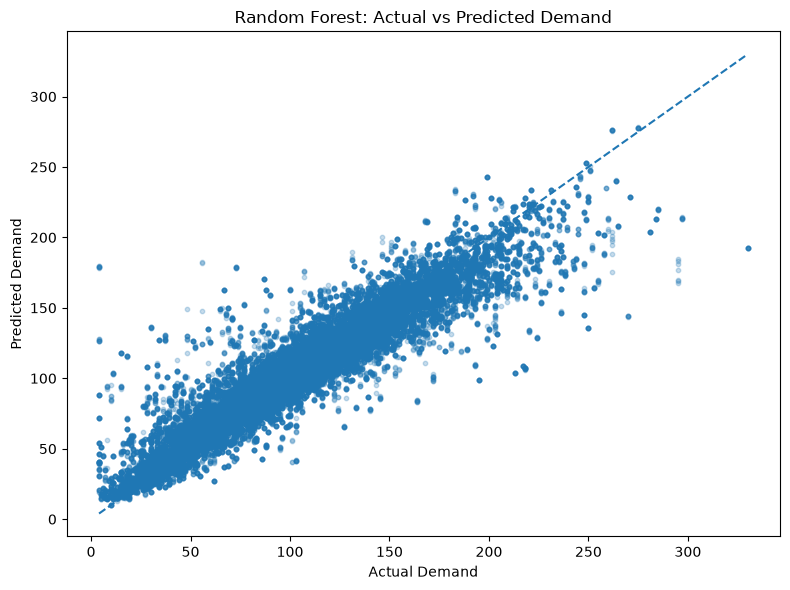

In [54]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rf_results['Actual_Demand'],
    rf_results['Predicted_Demand'],
    alpha=0.25,
    s=10
)

min_value = min(
    rf_results['Actual_Demand'].min(),
    rf_results['Predicted_Demand'].min()
)

max_value = max(
    rf_results['Actual_Demand'].max(),
    rf_results['Predicted_Demand'].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Random Forest: Actual vs Predicted Demand')

plt.tight_layout()
plt.show()

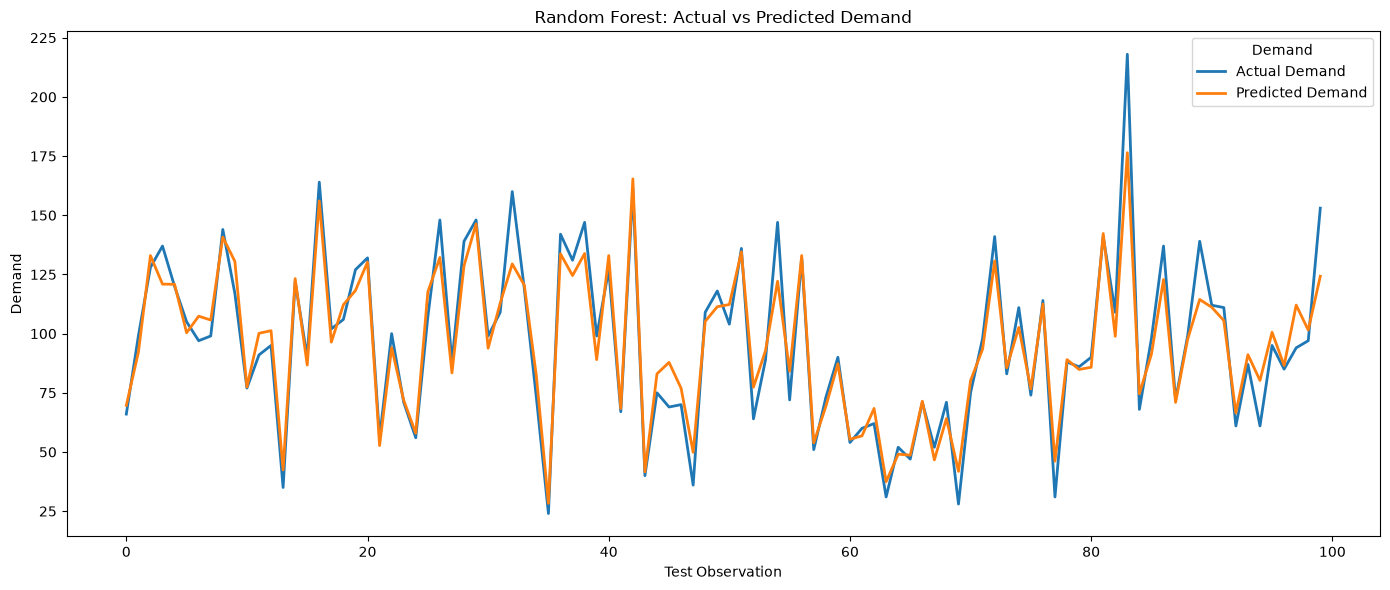

In [55]:
sample_size = 100

plt.figure(figsize=(14, 6))

plt.plot(
    rf_results['Actual_Demand'].iloc[:sample_size].values,
    label='Actual Demand',
    linewidth=2
)

plt.plot(
    rf_results['Predicted_Demand'].iloc[:sample_size].values,
    label='Predicted Demand',
    linewidth=2
)

plt.xlabel('Test Observation')
plt.ylabel('Demand')
plt.title('Random Forest: Actual vs Predicted Demand')

plt.legend(title='Demand')
plt.tight_layout()
plt.show()

### Residual Analysis

Residuals are examined to identify systematic overprediction or underprediction and changes in forecast-error variability across predicted demand levels.

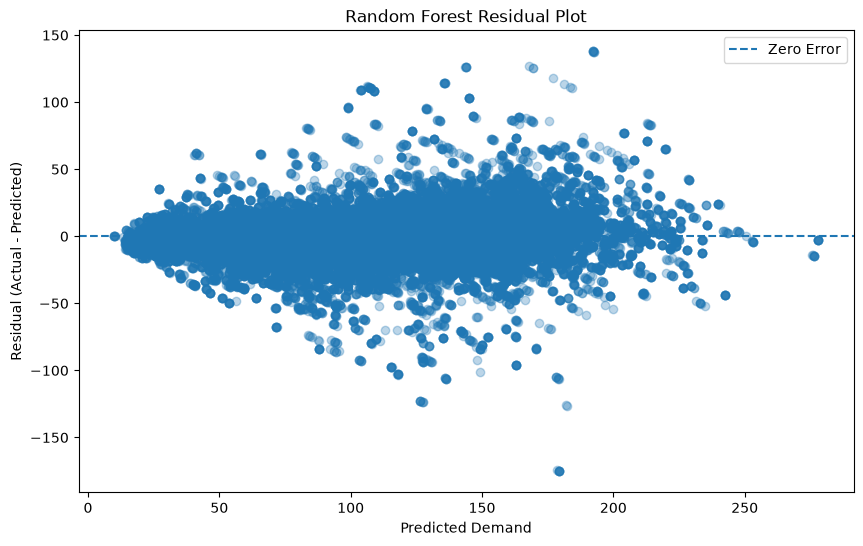

In [56]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rf_predictions,
    y_test - rf_predictions,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle='--',
    label='Zero Error'
)

plt.xlabel('Predicted Demand')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Random Forest Residual Plot')
plt.legend()

plt.show()

In [57]:
mean_error = np.mean(y_test - rf_predictions)

print(f"Mean Error (Bias): {mean_error:.2f}")

Mean Error (Bias): -0.35


#### Residual Summary

Residuals are distributed on both sides of zero, with little overall directional bias.

Most prediction errors remain relatively close to zero, although error variability increases for some higher-demand observations and several larger residuals remain.

### Largest Prediction Errors

The largest absolute forecasting errors are reviewed to identify situations where the final model is least reliable.

In [58]:
error_details = X_test.reset_index(drop=True).copy()

error_details['Actual_Demand'] = y_test.values
error_details['Predicted_Demand'] = rf_predictions

error_details['Error'] = (
    error_details['Actual_Demand']
    - error_details['Predicted_Demand']
)

error_details['Absolute_Error'] = (
    error_details['Error'].abs()
)

largest_error_details = (
    error_details
    .sort_values('Absolute_Error', ascending=False)
    .head(20)
)

largest_error_details[
    [
        'Store ID',
        'Product ID',
        'Category',
        'Forecast_Horizon',
        'Price',
        'Discount',
        'Promotion',
        'Weather Condition',
        'Seasonality',
        'Epidemic',
        'Actual_Demand',
        'Predicted_Demand',
        'Error',
        'Absolute_Error'
    ]
].round(2)

,Store ID,Product ID,Category,Forecast_Horizon,Price,Discount,Promotion,Weather Condition,Seasonality,Epidemic,Actual_Demand,Predicted_Demand,Error,Absolute_Error
24003,S004,P0004,Groceries,3,27.83,25.0,1.0,Sunny,Winter,0.0,4.0,179.37,-175.37,175.37
41775,S004,P0004,Groceries,5,27.83,25.0,1.0,Sunny,Winter,0.0,4.0,179.37,-175.37,175.37
14967,S004,P0004,Groceries,2,27.83,25.0,1.0,Sunny,Winter,0.0,4.0,179.36,-175.36,175.36
32939,S004,P0004,Groceries,4,27.83,25.0,1.0,Sunny,Winter,0.0,4.0,179.36,-175.36,175.36
59147,S004,P0004,Groceries,7,27.83,25.0,1.0,Sunny,Winter,0.0,4.0,179.29,-175.29,175.29
5831,S004,P0004,Groceries,1,27.83,25.0,1.0,Sunny,Winter,0.0,4.0,179.19,-175.19,175.19
50511,S004,P0004,Groceries,6,27.83,25.0,1.0,Sunny,Winter,0.0,4.0,178.59,-174.59,174.59
19056,S001,P0009,Clothing,3,167.34,0.0,0.0,Cloudy,Winter,0.0,330.0,192.22,137.78,137.78
28047,S001,P0009,Clothing,4,167.34,0.0,0.0,Cloudy,Winter,0.0,330.0,192.22,137.78,137.78
54420,S001,P0009,Clothing,7,167.34,0.0,0.0,Cloudy,Winter,0.0,330.0,192.22,137.78,137.78


In [59]:
extreme_combinations = [
    ('S004', 'P0004'),
    ('S001', 'P0009'),
    ('S003', 'P0010')
]

combination_stats = []

for store, product in extreme_combinations:
    
    subset = df[
        (df['Store ID'] == store) &
        (df['Product ID'] == product)
    ]
    
    combination_stats.append({
        'Store ID': store,
        'Product ID': product,
        'Min_Demand': subset['Demand'].min(),
        'Mean_Demand': subset['Demand'].mean(),
        'Median_Demand': subset['Demand'].median(),
        'Max_Demand': subset['Demand'].max()
    })

pd.DataFrame(combination_stats).round(2)

,Store ID,Product ID,Min_Demand,Mean_Demand,Median_Demand,Max_Demand
0,S004,P0004,4,123.11,119.5,327
1,S001,P0009,4,121.50,118.0,330
2,S003,P0010,4,120.94,118.0,305


#### Largest Error Summary

The largest errors are concentrated around extreme demand observations for a small number of store-product combinations.

The model tends to overpredict unusually low demand and underpredict some unusually high demand events, while maintaining strong performance across the broader test set.

These cases represent the main operational risk when using the forecasts for inventory decisions.

## 17. Business Interpretation and Recommendations

The final model results are translated into practical implications for short-term demand and inventory planning.

### Business Recommendations

The final model can support weekly replenishment and short-term stocking decisions by providing stable demand forecasts across a 7-day horizon.

Key considerations for operational use are:

- incorporate planned pricing, discounts, promotions, and relevant external conditions when generating forecasts;
- plan at store-product level because demand behaviour varies substantially across products and categories;
- combine model predictions with inventory availability, supplier lead times, safety stock, and service-level requirements;
- apply additional caution to unusually high or low demand situations, where the largest forecast errors occur; and
- monitor forecast accuracy over time and retrain the model when demand patterns or model performance change materially.

## 18. Project Conclusion

This project developed a machine learning solution for forecasting **daily store-product demand from 1 to 7 days ahead**.

Random Forest provided the strongest generalisation performance among the evaluated models and remained stable across the complete forecasting horizon. Model interpretation showed that demand forecasts rely strongly on product, pricing, promotional, and contextual information, while error analysis identified extreme demand events as the main source of forecasting risk.

The resulting model provides a strong foundation for a short-term demand forecasting and inventory-planning application, where forecasts can be combined with stock levels and operational constraints to support replenishment decisions.